In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('D:/Projects/Data Analytics/saas-churn-survival-analysis/data/processed/churn_clean.csv')

print(df.shape)
print(df['event'].value_counts())
print(f"Churn rate: {df['event'].mean()*100:.1f}%")

(7043, 26)
event
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


C:\Users\jagra\AppData\Local\Temp\ipykernel_16020\4158222264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='churn_pct',
C:\Users\jagra\AppData\Local\Temp\ipykernel_16020\4158222264.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2],


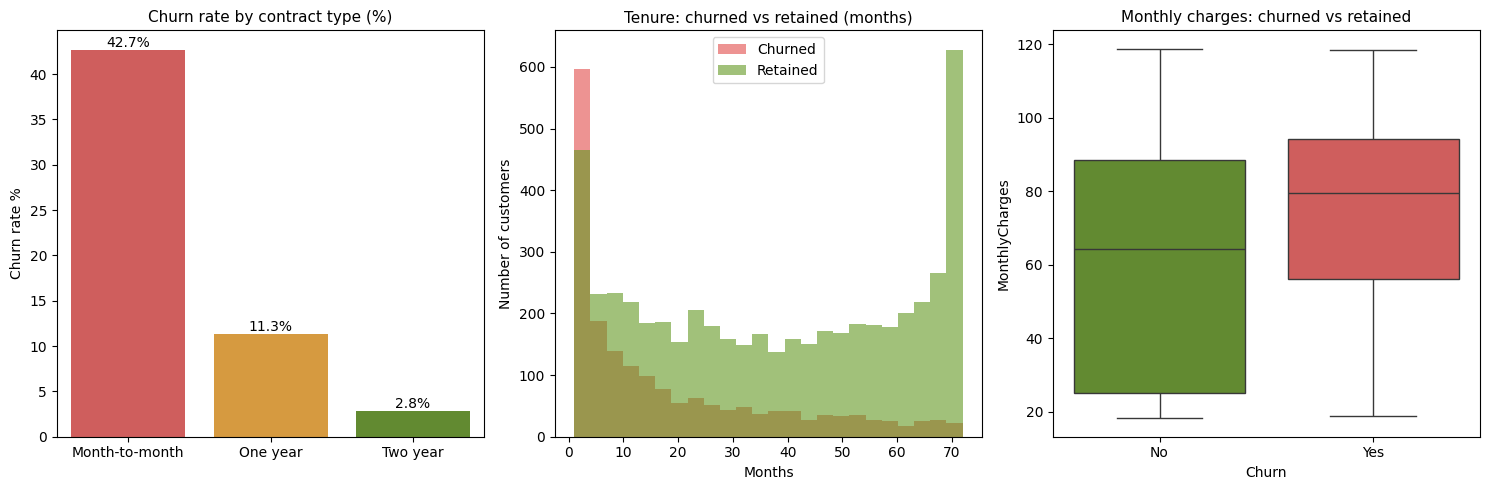

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — Churn rate by contract type
contract_churn = df.groupby('Contract')['event'].mean().reset_index()
contract_churn['churn_pct'] = (contract_churn['event'] * 100).round(1)

sns.barplot(data=contract_churn, x='Contract', y='churn_pct', 
            ax=axes[0], palette=['#E24B4A','#EF9F27','#639922'])
axes[0].set_title('Churn rate by contract type (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Churn rate %')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

# Chart 2 — Tenure distribution
churned = df[df['event']==1]['survival_time']
retained = df[df['event']==0]['survival_time']
axes[1].hist(churned, bins=24, alpha=0.6, label='Churned', color='#E24B4A')
axes[1].hist(retained, bins=24, alpha=0.6, label='Retained', color='#639922')
axes[1].set_title('Tenure: churned vs retained (months)', fontsize=11)
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Number of customers')
axes[1].legend()

# Chart 3 — Monthly charges boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2],
            palette={'No':'#639922','Yes':'#E24B4A'})
axes[2].set_title('Monthly charges: churned vs retained', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/charts/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\jagra\AppData\Local\Temp\ipykernel_16020\1556428767.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby(['tenure_band', 'Contract']).agg(


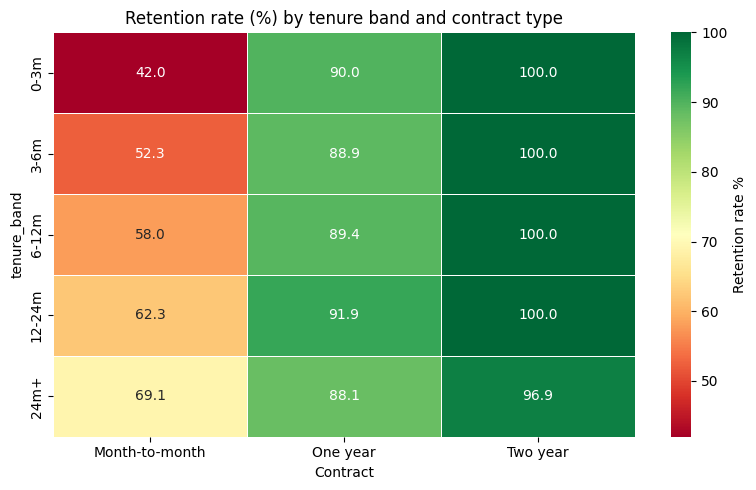

In [4]:
# Cohort retention heatmap
tenure_bins = [0, 3, 6, 12, 24, 72]
labels = ['0-3m', '3-6m', '6-12m', '12-24m', '24m+']
df['tenure_band'] = pd.cut(df['tenure'], bins=tenure_bins, labels=labels)

cohort = df.groupby(['tenure_band', 'Contract']).agg(
    total=('event', 'count'),
    churned=('event', 'sum')
).reset_index()
cohort['retention_rate'] = ((1 - cohort['churned'] / cohort['total']) * 100).round(1)

pivot = cohort.pivot(index='tenure_band', columns='Contract', values='retention_rate')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Retention rate %'})
plt.title('Retention rate (%) by tenure band and contract type')
plt.tight_layout()
plt.savefig('../outputs/charts/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\jagra\AppData\Local\Temp\ipykernel_16020\355488868.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_churn, x='InternetService', y='churn_pct',
C:\Users\jagra\AppData\Local\Temp\ipykernel_16020\355488868.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_churn, x='signup_channel', y='churn_pct',


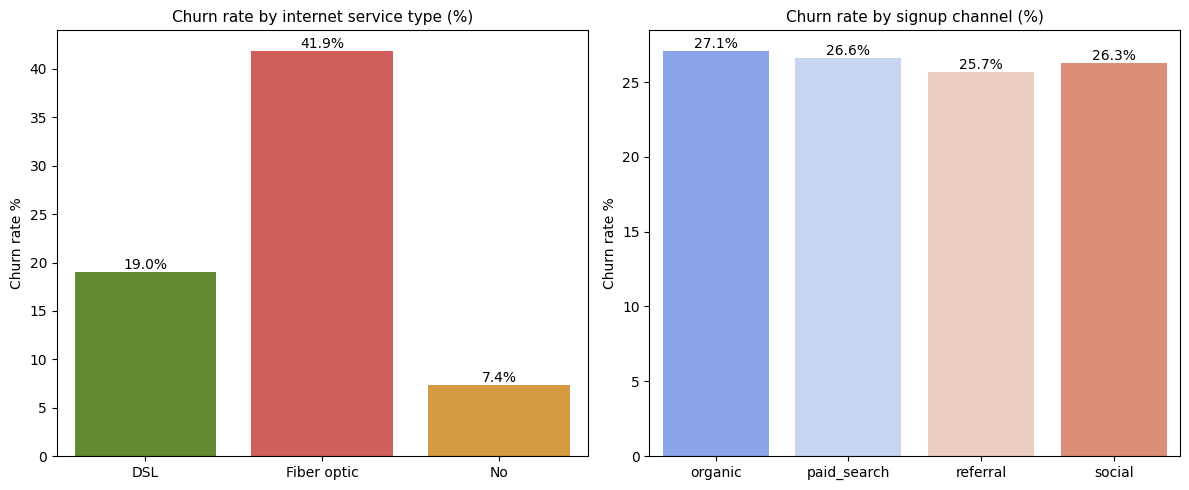

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Churn rate by internet service
internet_churn = df.groupby('InternetService')['event'].mean().reset_index()
internet_churn['churn_pct'] = (internet_churn['event'] * 100).round(1)

sns.barplot(data=internet_churn, x='InternetService', y='churn_pct',
            ax=axes[0], palette=['#639922','#E24B4A','#EF9F27'])
axes[0].set_title('Churn rate by internet service type (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Churn rate %')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

# Chart 2 — Churn rate by signup channel
channel_churn = df.groupby('signup_channel')['event'].mean().reset_index()
channel_churn['churn_pct'] = (channel_churn['event'] * 100).round(1)

sns.barplot(data=channel_churn, x='signup_channel', y='churn_pct',
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Churn rate by signup channel (%)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Churn rate %')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/churn_by_service_channel.png', dpi=150, bbox_inches='tight')
plt.show()

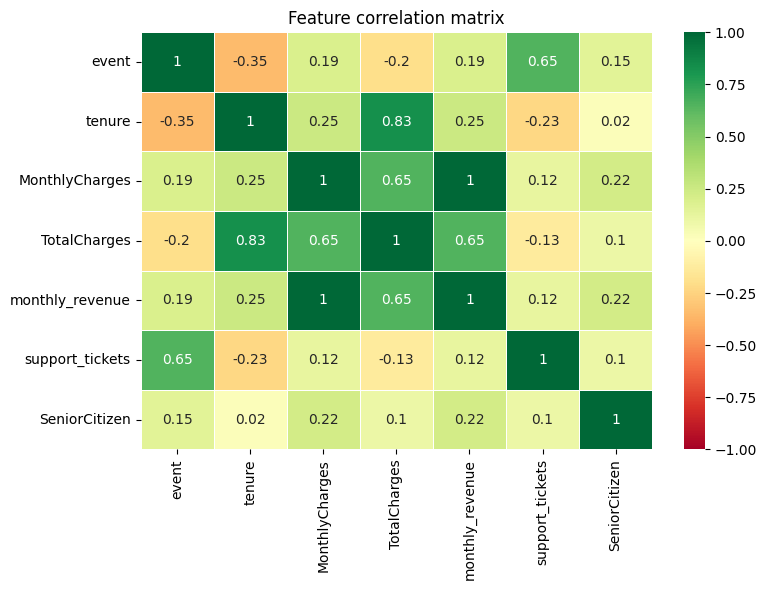

In [6]:
# Correlation heatmap
corr_cols = ['event','tenure','MonthlyCharges','TotalCharges',
             'monthly_revenue','support_tickets','SeniorCitizen']

df_corr = df[corr_cols].copy()
df_corr['SeniorCitizen'] = (df_corr['SeniorCitizen'] == 'Yes').astype(int)

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr().round(2), annot=True, cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../outputs/charts/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
tenure_bins = [0, 3, 6, 12, 24, 72]
labels = ['0-3m', '3-6m', '6-12m', '12-24m', '24m+']
df['tenure_band'] = pd.cut(df['tenure'], bins=tenure_bins, labels=labels)

cohort = df.groupby(['tenure_band', 'Contract']).agg(
    total=('event', 'count'),
    churned=('event', 'sum')
).reset_index()
cohort['retention_rate'] = ((1 - cohort['churned'] / cohort['total']) * 100).round(1)

cohort.to_csv('../outputs/tableau_data/cohort_retention.csv', index=False)
print("Saved")
print(cohort)

Saved
   tenure_band        Contract  total  churned  retention_rate
0         0-3m  Month-to-month   1025      595            42.0
1         0-3m        One year     20        2            90.0
2         0-3m        Two year      6        0           100.0
3         3-6m  Month-to-month    388      185            52.3
4         3-6m        One year     18        2            88.9
5         3-6m        Two year     13        0           100.0
6        6-12m  Month-to-month    581      244            58.0
7        6-12m        One year     85        9            89.4
8        6-12m        Two year     39        0           100.0
9       12-24m  Month-to-month    737      278            62.3
10      12-24m        One year    197       16            91.9
11      12-24m        Two year     90        0           100.0
12        24m+  Month-to-month   1144      353            69.1
13        24m+        One year   1152      137            88.1
14        24m+        Two year   1537       48   

C:\Users\jagra\AppData\Local\Temp\ipykernel_16020\737738080.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby(['tenure_band', 'Contract']).agg(
